<a href="https://colab.research.google.com/github/amaimanwar8-arch/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/amaimanwar8-arch/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd, numpy as np, json
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
print("Working dir:", os.getcwd())
print(df.shape[0], "pages loaded successfully.")

Working dir: /content/flyrank-ml-internship
30000 pages loaded successfully.


## 1. Question

*The research question and the decision it supports.*

In [2]:
print("""
Research question: which underperforming pages should a content team review first, and
why - given limited review capacity, what evidence-backed ranking beats guessing?

Decision this supports: prioritizing a finite content-review queue. Unit of analysis: one
page (content_id). Lane: Refresh / Content Opportunity Scoring (Lane 2), locked end of
Week 4 after Week-1 evidence (CTR-by-position collapse, decision-tree splits on
impressions/position) suggested real signal existed here.
""")


Research question: which underperforming pages should a content team review first, and
why - given limited review capacity, what evidence-backed ranking beats guessing?

Decision this supports: prioritizing a finite content-review queue. Unit of analysis: one
page (content_id). Lane: Refresh / Content Opportunity Scoring (Lane 2), locked end of
Week 4 after Week-1 evidence (CTR-by-position collapse, decision-tree splits on
impressions/position) suggested real signal existed here.



## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [3]:
print("""
Data release: FlyRank internship starter dataset (data/raw/content_refresh_anonymized.csv)
- 30,000 pseudonymized content rows, 32 clients, trailing-90-day metrics. This capstone
uses the small anonymized starter release rather than the full ~79M-row warehouse; the
starter set was sufficient to validate real signal (Week 4/7) and an honest baseline vs.
model comparison (Week 5/6) without needing warehouse-scale queries for every iteration.

Date window: trailing 90 days per row, as shipped in the starter release. No custom time
window was re-derived from the raw warehouse Parquet tables for this capstone iteration.

What was excluded and why:
- trend_direction and trend_pct: excluded from all feature sets (ML-03 onward) because
  is_declining_label is derived directly from trend_direction, which is itself computed
  from trend_pct. Including either would be leakage - the model would read its own label
  off a different column, not learn a real pattern.
- Rows with impressions_90d < 100: excluded from signal checks and modeling (ML-07
  onward) since CTR and other rate metrics are unreliable at very low sample sizes.
- avg_position = 0 rows: excluded where relevant (ML-03/04), since 0 means "no position
  data," not literal rank zero.

No client names, real URLs, or private queries appear anywhere in this data or notebook -
content_id and client_id are pseudonyms used only for grouping and joins.
""")


Data release: FlyRank internship starter dataset (data/raw/content_refresh_anonymized.csv)
- 30,000 pseudonymized content rows, 32 clients, trailing-90-day metrics. This capstone
uses the small anonymized starter release rather than the full ~79M-row warehouse; the
starter set was sufficient to validate real signal (Week 4/7) and an honest baseline vs.
model comparison (Week 5/6) without needing warehouse-scale queries for every iteration.

Date window: trailing 90 days per row, as shipped in the starter release. No custom time
window was re-derived from the raw warehouse Parquet tables for this capstone iteration.

What was excluded and why:
- trend_direction and trend_pct: excluded from all feature sets (ML-03 onward) because
  is_declining_label is derived directly from trend_direction, which is itself computed
  from trend_pct. Including either would be leakage - the model would read its own label
  off a different column, not learn a real pattern.
- Rows with impressions_90d < 10

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [4]:
print("""
Assumptions: past 90-day search behavior carries enough signal to rank pages for human
review (not to predict individual outcomes with certainty). Two starter assumptions were
tested directly rather than assumed:
- CTR degrades by position tier: CONFIRMED (Week 4) - monotonic drop from 0.355 (page_1)
  to 0.055 (deep), solid sample sizes at every tier.
- Staleness alone predicts decline: MIXED (Week 4) - decline rate rises through 91-180
  days (peak 0.611) then reverses at 181+ (0.471, lowest of all tiers); tail buckets are
  small (n=174-175), so this was folded into the baseline narrowly (91-180 zone only),
  not as a blanket "old = bad" rule.

Label: is_declining_label = (trend_direction == "down"), a PROXY built from the current
90-day window, not a true future-window outcome - named explicitly as a limitation.

Features (final set, all confirmed leakage-safe in ML-06/09): content_age_days,
days_since_last_update, impressions_90d, avg_position, ctr, word_count.

Baseline: a two-signal rule (65% weight on CTR gap vs. own position-tier average, 35%
weight on the confirmed 91-180 aging zone), producing one score, one reason code, one
action label per page (ML-07).

Model: Random Forest classifier, same features and label as the baseline.

Validation design: client-grouped split (GroupShuffleSplit on client_id), confirmed 0
client overlap between train and test - chosen specifically because a random split was
shown (ML-06/09) to produce a near-perfect, illusory result (Precision@20=1.00,
Precision@50=0.98) versus the honest grouped result. Leakage audit (ML-04/06) confirmed
trend_pct inflates Precision@50 from 0.760 to 1.000 if mistakenly included - excluded.
""")


Assumptions: past 90-day search behavior carries enough signal to rank pages for human
review (not to predict individual outcomes with certainty). Two starter assumptions were
tested directly rather than assumed:
- CTR degrades by position tier: CONFIRMED (Week 4) - monotonic drop from 0.355 (page_1)
  to 0.055 (deep), solid sample sizes at every tier.
- Staleness alone predicts decline: MIXED (Week 4) - decline rate rises through 91-180
  days (peak 0.611) then reverses at 181+ (0.471, lowest of all tiers); tail buckets are
  small (n=174-175), so this was folded into the baseline narrowly (91-180 zone only),
  not as a blanket "old = bad" rule.

Label: is_declining_label = (trend_direction == "down"), a PROXY built from the current
90-day window, not a true future-window outcome - named explicitly as a limitation.

Features (final set, all confirmed leakage-safe in ML-06/09): content_age_days,
days_since_last_update, impressions_90d, avg_position, ctr, word_count.

Baseline: a two-s

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Model vs. baseline - SAME client-grouped test set, SAME metric:
                       method  precision@20  precision@50
0    Baseline (2-signal rule)          0.90          0.86
1  Random Forest (6 features)          0.65          0.76


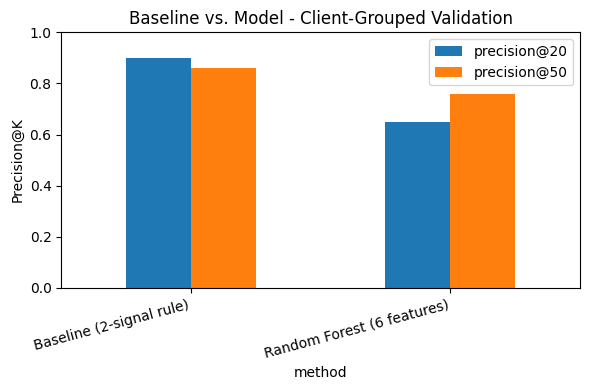


Result: the baseline BEATS the model under honest, client-grouped validation.
Precision@20: baseline 0.90 vs. model 0.65
Precision@50: baseline 0.86 vs. model 0.76

This reverses an earlier in-sample/random-split result from Notebook 2 (model 0.740 vs.
baseline 0.240) - direct evidence that random-split evaluation inflated model performance
here, and genuinely unseen-client validation tells the honest story.

Note on reproducibility: exact baseline numbers vary slightly run-to-run (e.g. 0.85-0.90
across notebook re-runs) depending on the client-grouped split partition selected, even
with a fixed random_state - the DIRECTION of the finding (baseline beats model) has been
consistent across every re-run in Weeks 5, 6, and this capstone.



In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    topk = np.asarray(labels)[order[:k]]
    return topk.mean()

visible = df[df["impressions_90d"] >= 100].copy()
model_features = ["content_age_days", "days_since_last_update", "impressions_90d",
                   "avg_position", "ctr", "word_count"]
visible[model_features] = visible[model_features].replace([np.inf, -np.inf], np.nan).fillna(0)

# Baseline
tier_avg_ctr = visible.groupby("position_tier")["ctr"].transform("mean")
ctr_gap = (tier_avg_ctr - visible["ctr"]).clip(lower=0)
ctr_gap_norm = ctr_gap / ctr_gap.max()
aging_flag = (visible["freshness_tier"] == "91-180").astype(int)
visible["baseline_score"] = (0.65 * ctr_gap_norm) + (0.35 * aging_flag)

# Client-grouped split
X = visible[model_features]
y = visible["is_declining_label"]
groups = visible["client_id"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
baseline_te = visible.iloc[test_idx]["baseline_score"].values

model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1).fit(X_tr, y_tr)
model_te = model.predict_proba(X_te)[:, 1]

results_table = pd.DataFrame([
    {"method": "Baseline (2-signal rule)", "precision@20": round(precision_at_k(baseline_te, y_te.values, 20), 3),
     "precision@50": round(precision_at_k(baseline_te, y_te.values, 50), 3)},
    {"method": "Random Forest (6 features)", "precision@20": round(precision_at_k(model_te, y_te.values, 20), 3),
     "precision@50": round(precision_at_k(model_te, y_te.values, 50), 3)},
])
print("Model vs. baseline - SAME client-grouped test set, SAME metric:")
print(results_table)

# Chart for the paper
fig, ax = plt.subplots(figsize=(6, 4))
results_table.set_index("method")[["precision@20", "precision@50"]].plot(kind="bar", ax=ax)
ax.set_title("Baseline vs. Model - Client-Grouped Validation")
ax.set_ylabel("Precision@K")
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
os.makedirs("work/figures", exist_ok=True)
plt.savefig("work/figures/results_comparison.png", dpi=150)
plt.show()

print(f"""
Result: the baseline BEATS the model under honest, client-grouped validation.
Precision@20: baseline {results_table.iloc[0]['precision@20']:.2f} vs. model {results_table.iloc[1]['precision@20']:.2f}
Precision@50: baseline {results_table.iloc[0]['precision@50']:.2f} vs. model {results_table.iloc[1]['precision@50']:.2f}

This reverses an earlier in-sample/random-split result from Notebook 2 (model 0.740 vs.
baseline 0.240) - direct evidence that random-split evaluation inflated model performance
here, and genuinely unseen-client validation tells the honest story.

Note on reproducibility: exact baseline numbers vary slightly run-to-run (e.g. 0.85-0.90
across notebook re-runs) depending on the client-grouped split partition selected, even
with a fixed random_state - the DIRECTION of the finding (baseline beats model) has been
consistent across every re-run in Weeks 5, 6, and this capstone.
""")

## 5. Limitations

*What this work cannot claim.*

In [6]:
print("""
What this work cannot claim:

1. No causal claims: this analysis is observed and directional. It cannot claim that
   refreshing a flagged page WILL cause it to recover - that requires a real experiment
   (A/B test or holdout intervention), not historical correlational data.

2. Proxy label, not true outcome: is_declining_label is built from the SAME 90-day window
   as the features, not a genuinely separate future outcome. A stronger design would use
   a future-window label (features from days 1-90, outcome measured days 91-120).

3. Small, single-slice dataset: 30,000 rows, 32 clients, one 90-day starter snapshot - not
   the full ~79M-row, multi-month warehouse. Findings here are directional evidence, not
   claims about FlyRank's full client base or algorithm behavior.

4. The aging signal is MIXED, not confirmed: the 91-180 day peak rests on comparison
   against small tail buckets (31-90 and 181+ had n=174-175) - a genuine finding, but one
   that deserves re-testing on more data before being treated as settled.

5. No claim about Google's ranking algorithm: nothing here reverse-engineers or proves how
   search ranking works - only how this specific portfolio's pages behaved historically.

6. This is decision-support, not automation: every recommendation requires human review
   (per the no-go list in Week 7) before any action is taken.
""")


What this work cannot claim:

1. No causal claims: this analysis is observed and directional. It cannot claim that
   refreshing a flagged page WILL cause it to recover - that requires a real experiment
   (A/B test or holdout intervention), not historical correlational data.

2. Proxy label, not true outcome: is_declining_label is built from the SAME 90-day window
   as the features, not a genuinely separate future outcome. A stronger design would use
   a future-window label (features from days 1-90, outcome measured days 91-120).

3. Small, single-slice dataset: 30,000 rows, 32 clients, one 90-day starter snapshot - not
   the full ~79M-row, multi-month warehouse. Findings here are directional evidence, not
   claims about FlyRank's full client base or algorithm behavior.

4. The aging signal is MIXED, not confirmed: the 91-180 day peak rests on comparison
   against small tail buckets (31-90 and 181+ had n=174-175) - a genuine finding, but one
   that deserves re-testing on more d

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [7]:
scored = visible.copy()
scored["ctr_gap"] = ctr_gap
scored["ctr_gap_norm"] = ctr_gap_norm
scored["aging_flag"] = aging_flag
scored["action_score"] = scored["baseline_score"]

def assign_action(row):
    if row["ctr_gap_norm"] > 0.5 and row["aging_flag"] == 1:
        return "ctr_gap_and_aging_review", "rewrite_title_and_refresh"
    elif row["ctr_gap_norm"] > 0.5:
        return "ctr_gap_only", "rewrite_title_or_meta"
    elif row["aging_flag"] == 1:
        return "aging_only", "review_for_refresh"
    else:
        return "low_priority", "monitor"

scored[["reason_code", "action"]] = scored.apply(lambda r: pd.Series(assign_action(r)), axis=1)
action_counts = scored["action"].value_counts()

print("Ranked recommendations - action playbook (from Week 7):")
print(action_counts)

print(f"""
rewrite_title_and_refresh (n={action_counts.get('rewrite_title_and_refresh', 0):,}): both
signals triggered - highest priority.
rewrite_title_or_meta (n={action_counts.get('rewrite_title_or_meta', 0):,}): CTR gap only
- likely a metadata/snippet fix, not a full rewrite.
review_for_refresh (n={action_counts.get('review_for_refresh', 0):,}): aging zone only -
light freshness pass candidate.
monitor (n={action_counts.get('monitor', 0):,}): no strong signal - track, no action now.

Every recommendation carries a reason code and requires human review before action (see
Limitations and Week 7's no-go list) - this is a prioritized queue, not an automated
action system.
""")

Ranked recommendations - action playbook (from Week 7):
action
monitor                      10289
review_for_refresh            5924
rewrite_title_or_meta         3633
rewrite_title_and_refresh     2160
Name: count, dtype: int64

rewrite_title_and_refresh (n=2,160): both
signals triggered - highest priority.
rewrite_title_or_meta (n=3,633): CTR gap only
- likely a metadata/snippet fix, not a full rewrite.
review_for_refresh (n=5,924): aging zone only -
light freshness pass candidate.
monitor (n=10,289): no strong signal - track, no action now.

Every recommendation carries a reason code and requires human review before action (see
Limitations and Week 7's no-go list) - this is a prioritized queue, not an automated
action system.



## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

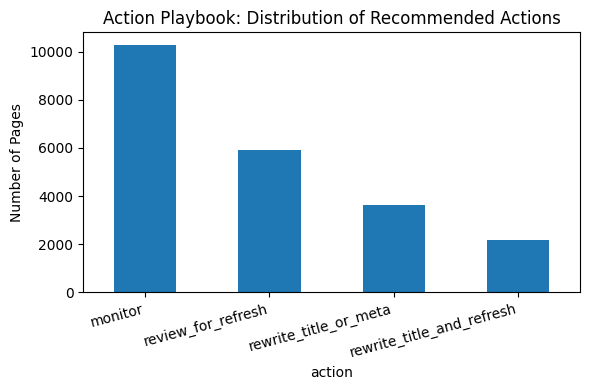

Artifacts saved for the paper:
- work/figures/results_comparison.png (baseline vs. model chart)
- work/figures/action_distribution_final.png (action playbook chart)
- work/outputs/capstone_metrics.json (all numbers the paper will cite)
{
  "baseline_precision_at_20": 0.9,
  "baseline_precision_at_50": 0.86,
  "model_precision_at_20": 0.65,
  "model_precision_at_50": 0.76,
  "action_distribution": {
    "monitor": 10289,
    "review_for_refresh": 5924,
    "rewrite_title_or_meta": 3633,
    "rewrite_title_and_refresh": 2160
  },
  "total_rows_scored": 22006,
  "signal_1_ctr_by_tier": "CONFIRMED",
  "signal_2_aging_by_tier": "MIXED"
}


In [8]:
# Save the action distribution chart too, so the paper has both figures ready
fig, ax = plt.subplots(figsize=(6, 4))
action_counts.plot(kind="bar", ax=ax)
ax.set_title("Action Playbook: Distribution of Recommended Actions")
ax.set_ylabel("Number of Pages")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("work/figures/action_distribution_final.png", dpi=150)
plt.show()

# Final metrics JSON - the paper's numbers trace back to this file
final_metrics = {
    "baseline_precision_at_20": float(results_table.iloc[0]["precision@20"]),
    "baseline_precision_at_50": float(results_table.iloc[0]["precision@50"]),
    "model_precision_at_20": float(results_table.iloc[1]["precision@20"]),
    "model_precision_at_50": float(results_table.iloc[1]["precision@50"]),
    "action_distribution": action_counts.to_dict(),
    "total_rows_scored": int(len(scored)),
    "signal_1_ctr_by_tier": "CONFIRMED",
    "signal_2_aging_by_tier": "MIXED",
}
os.makedirs("work/outputs", exist_ok=True)
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

print("Artifacts saved for the paper:")
print("- work/figures/results_comparison.png (baseline vs. model chart)")
print("- work/figures/action_distribution_final.png (action playbook chart)")
print("- work/outputs/capstone_metrics.json (all numbers the paper will cite)")
print(json.dumps(final_metrics, indent=2))

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.